In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
import seaborn as sns
from Scripts.Random_forest_nested import *


Import logistic unadjusted

In [4]:

with open("results_adjusted_7y.pkl", "rb") as f:
    data_7_ad = pickle.load(f)

with open("results_adjusted_12y.pkl", "rb") as g:
    data_12_ad = pickle.load(g)
with open("results_adjusted_18y.pkl", "rb") as f:
    data_18_ad = pickle.load(f)


In [5]:
with open("results_7y.pkl", "rb") as f:
    data_7 = pickle.load(f)

with open("results_12y.pkl", "rb") as g:
    data_12 = pickle.load(g)
with open("results_18y.pkl", "rb") as f:
    data_18 = pickle.load(f)


In [6]:
with open("results_rf_7y.pkl", "rb") as f:
    data_7_rf = pickle.load(f)

with open("results_rf_12y.pkl", "rb") as g:
    data_12_rf = pickle.load(g)
with open("results_rf_18y.pkl", "rb") as f:
    data_18_rf = pickle.load(f)


In [7]:
with open("results_rf_7y_adjusted.pkl", "rb") as f:
    data_7_rf_ad = pickle.load(f)

with open("results_rf_12y_adjusted.pkl", "rb") as g:
    data_12_rf_ad = pickle.load(g)
with open("results_rf_18y_adjusted.pkl", "rb") as f:
    data_18_rf_ad = pickle.load(f)


In [8]:
data_18_rf_ad

{'summary': {'model': 'calibrated_rf',
  'calibration': 'sigmoid',
  'calibration_ensemble': False,
  'grouped_cv': False,
  'n_repeats': 5,
  'n_splits': 5,
  'n_folds': 25,
  'n_samples': 411,
  'n_features': 17,
  'prevalence': 0.22871046228710462,
  'bss_baseline': 'applied',
  'mean_fold_baseline_brier': 0.17641422715188734,
  'test_auc_mean': 0.6018739557226399,
  'test_auc_sd': 0.06082857668524678,
  'test_auc_q05': 0.5259398496240602,
  'test_auc_q95': 0.7033390768588137,
  'test_brier_mean': 0.17318404208194602,
  'test_bss_mean': 0.018298227752171648,
  'test_bss_sd': 0.024415823224499783,
  'test_ici_mean': 0.049976051053697096,
  'pooled_oof_auc': 0.6022216256124572,
  'pooled_oof_brier': 0.17246470200326405,
  'pooled_oof_bss': 0.022387792710294674,
  'pooled_oof_ici': 0.02112795025521597,
  'pooled_note': "pooled_oof_* averages each row's prediction over the repeats and is therefore an ensemble; report the fold-wise test_* as primary",
  'train_apparent_auc_mean': 0.86158

In [7]:
def performence(data):
    roc=np.block([data['fold_metrics']['auc_train_apparent'].mean(),np.quantile(data['fold_metrics']['auc_train_apparent'], [0.05,0.95])])
    bss=np.block([data['fold_metrics']['bss_train_apparent'].mean(),np.quantile(data['fold_metrics']['bss_train_apparent'], [0.05,0.95])])
    ici=np.block([data['fold_metrics']['ici_train_apparent'].mean(),np.quantile(data['fold_metrics']['ici_train_apparent'], [0.05,0.95])])
    roc_test=np.block([data['fold_metrics']['auc_test'].mean(),np.quantile(data['fold_metrics']['auc_test'], [0.05,0.95])])
    bss_test=np.block([data['fold_metrics']['bss_test'].mean(),np.quantile(data['fold_metrics']['bss_test'], [0.05,0.95])])
    ici_test=np.block([data['fold_metrics']['ici_test'].mean(),np.quantile(data['fold_metrics']['ici_test'], [0.05,0.95])])
    return pd.DataFrame(np.array([roc,bss,ici,roc_test,bss_test,ici_test]).T,columns=["ROC","BSS","ICI","ROC_test","BSS_test","ICI_test"],index=["mean","0.05","0.95"])

In [8]:
def performence_lg(data):
    roc=np.block([data['performance_train']['roc_train'].mean(),np.quantile(data['performance_train']['roc_train'], [0.05,0.95])])
    bss=np.block([data['performance_train']['bss_train'].mean(),np.quantile(data['performance_train']['bss_train'], [0.05,0.95])])
    ici=np.block([data['performance_train']['ici_train'].mean(),np.quantile(data['performance_train']['ici_train'], [0.05,0.95])])
    roc_test=np.block([data['performance_test']['roc_test'].mean(),np.quantile(data['performance_test']['roc_test'], [0.05,0.95])])
    bss_test=np.block([data['performance_test']['bss_test'].mean(),np.quantile(data['performance_test']['bss_test'], [0.05,0.95])])
    ici_test=np.block([data['performance_test']['ici_test'].mean(),np.quantile(data['performance_test']['ici_test'], [0.05,0.95])])
    return pd.DataFrame(np.array([roc,bss,ici,roc_test,bss_test,ici_test]).T,columns=["ROC","BSS","ICI","ROC_test","BSS_test","ICI_test"],index=["mean","0.05","0.95"])

In [10]:
performance(data_7_rf_ad)

NameError: name 'performance' is not defined

In [19]:
performence(data_7_rf)

,ROC,BSS,ICI,ROC_test,BSS_test,ICI_test
mean,0.842961,0.121118,0.105094,0.611017,0.016676,0.055739
0.05,0.795034,0.061000,0.069663,0.472269,-0.059571,0.032070
0.95,0.888879,0.183294,0.149013,0.768697,0.051479,0.096176


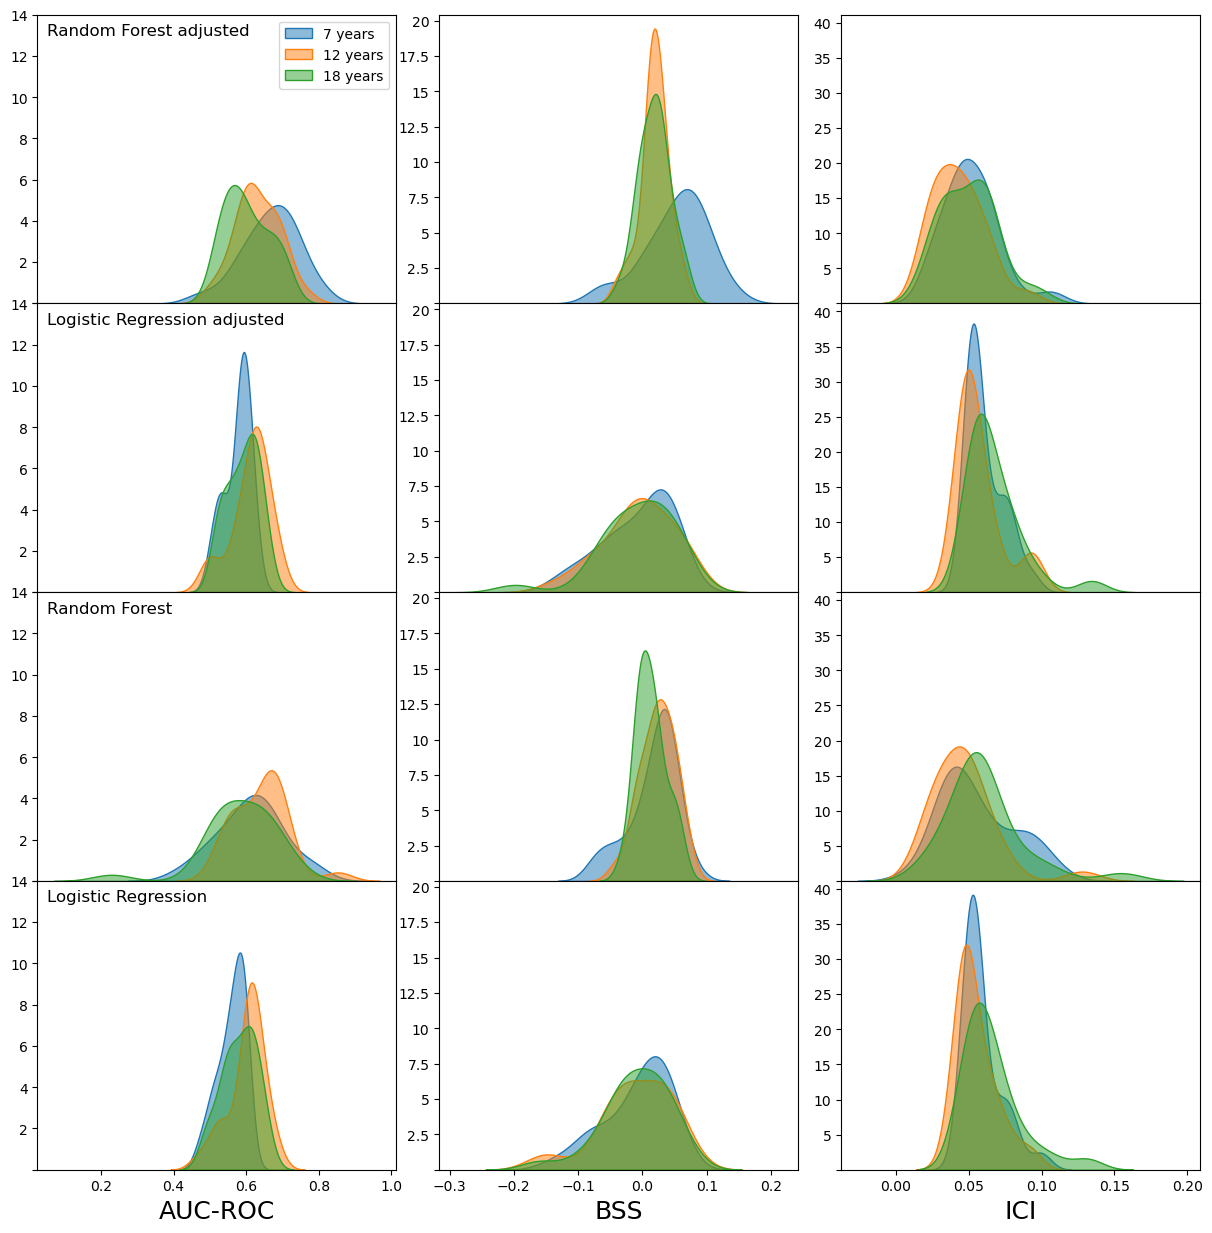

In [13]:
fig,ax=plt.subplots(4,3,figsize=(15,15),sharex="col",sharey="col", gridspec_kw={'wspace': 0.12, 'hspace': 0.00})
sns.kdeplot(data_7_rf_ad['fold_metrics']['auc_test'],ax=ax[0,0],fill=True,alpha=0.5,label=r"7 years")
sns.kdeplot(data_12_rf_ad['fold_metrics']['auc_test'],ax=ax[0,0],fill=True,alpha=0.5,label=r"12 years")
sns.kdeplot(data_18_rf_ad['fold_metrics']['auc_test'],ax=ax[0,0],fill=True,alpha=0.5,label=r"18 years")
ax[0,0].legend(loc=1)

sns.kdeplot(data_7_ad['performance_test']['roc_test'].mean(axis=1),ax=ax[1,0],fill=True,alpha=0.5,label="7 years LR adjusted ROC: "+str(np.round(data_7_ad['performance_test']['roc_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_12_ad['performance_test']['roc_test'].mean(axis=1),ax=ax[1,0],fill=True,alpha=0.5,label="12 years LR adjusted ROC: "+str(np.round(data_12_ad['performance_test']['roc_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_18_ad['performance_test']['roc_test'].mean(axis=1),ax=ax[1,0],fill=True,alpha=0.5,label="18 years LR adjusted ROC: "+str(np.round(data_18_ad['performance_test']['roc_test'].mean(axis=1).mean(),2)))




sns.kdeplot(data_7_rf_ad['fold_metrics']['bss_test'],ax=ax[0,1],fill=True,alpha=0.5,label="7 years RF adjusted BSS: "+str(np.round(data_7_rf_ad['fold_metrics']['bss_test'].mean(),2)))
sns.kdeplot(data_12_rf_ad['fold_metrics']['bss_test'],ax=ax[0,1],fill=True,alpha=0.5,label="12 years RF adjusted BSS: "+str(np.round(data_12_rf_ad['fold_metrics']['bss_test'].mean(),2)))
sns.kdeplot(data_18_rf_ad['fold_metrics']['bss_test'],ax=ax[0,1],fill=True,alpha=0.5,label="18 years RF adjusted BSS: "+str(np.round(data_18_rf_ad['fold_metrics']['bss_test'].mean(),2)))

sns.kdeplot(data_7_ad['performance_test']['bss_test'].mean(axis=1),ax=ax[1,1],fill=True,alpha=0.5,label="7 years LR adjusted BSS: "+str(np.round(data_7_ad['performance_test']['bss_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_12_ad['performance_test']['bss_test'].mean(axis=1),ax=ax[1,1],fill=True,alpha=0.5,label="12 years LR adjusted BSS: "+str(np.round(data_12_ad['performance_test']['bss_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_18_ad['performance_test']['bss_test'].mean(axis=1),ax=ax[1,1],fill=True,alpha=0.5,label="18 years LR adjusted BSS: "+str(np.round(data_18_ad['performance_test']['bss_test'].mean(axis=1).mean(),2)))






sns.kdeplot(data_7_rf_ad['fold_metrics']['ici_test'],ax=ax[0,2],fill=True,alpha=0.5,label="7 years RF adjusted ICI: "+str(np.round(data_7_rf_ad['fold_metrics']['ici_test'].mean(),2)))
sns.kdeplot(data_12_rf_ad['fold_metrics']['ici_test'],ax=ax[0,2],fill=True,alpha=0.5,label="12 years RF adjusted ICI: "+str(np.round(data_12_rf_ad['fold_metrics']['ici_test'].mean(),2)))
sns.kdeplot(data_18_rf_ad['fold_metrics']['ici_test'],ax=ax[0,2],fill=True,alpha=0.5,label="18 years RF adjusted ICI: "+str(np.round(data_18_rf_ad['fold_metrics']['ici_test'].mean(),2)))

sns.kdeplot(data_7_ad['performance_test']['ici_test'].mean(axis=1),ax=ax[1,2],fill=True,alpha=0.5,label="7 years adjusted ICI: "+str(np.round(data_7_ad['performance_test']['ici_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_12_ad['performance_test']['ici_test'].mean(axis=1),ax=ax[1,2],fill=True,alpha=0.5,label="12 years adjusted ICI: "+str(np.round(data_12_ad['performance_test']['ici_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_18_ad['performance_test']['ici_test'].mean(axis=1),ax=ax[1,2],fill=True,alpha=0.5,label="18 years adjusted BSS: "+str(np.round(data_18_ad['performance_test']['ici_test'].mean(axis=1).mean(),2)))




sns.kdeplot(data_7_rf['fold_metrics']['auc_test'],ax=ax[2,0],fill=True,alpha=0.5,label="7 years RF ROC: "+str(np.round(data_7_rf['fold_metrics']['auc_test'].mean(),2)))
sns.kdeplot(data_12_rf['fold_metrics']['auc_test'],ax=ax[2,0],fill=True,alpha=0.5,label="12 years RF ROC: "+str(np.round(data_12_rf['fold_metrics']['auc_test'].mean(),2)))
sns.kdeplot(data_18_rf['fold_metrics']['auc_test'],ax=ax[2,0],fill=True,alpha=0.5,label="18 years RF adjusted ROC: "+str(np.round(data_18_rf['fold_metrics']['auc_test'].mean(),2)))

sns.kdeplot(data_7['performance_test']['roc_test'].mean(axis=1),ax=ax[3,0],fill=True,alpha=0.5,label="7 years LR ROC: "+str(np.round(data_7['performance_test']['roc_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_12['performance_test']['roc_test'].mean(axis=1),ax=ax[3,0],fill=True,alpha=0.5,label="12 years LR ROC: "+str(np.round(data_12['performance_test']['roc_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_18['performance_test']['roc_test'].mean(axis=1),ax=ax[3,0],fill=True,alpha=0.5,label="18 years LR ROC: "+str(np.round(data_18['performance_test']['roc_test'].mean(axis=1).mean(),2)))




sns.kdeplot(data_7_rf['fold_metrics']['bss_test'],ax=ax[2,1],fill=True,alpha=0.5,label="7 years RF BSS: "+str(np.round(data_7_rf['fold_metrics']['bss_test'].mean(),2)))
sns.kdeplot(data_12_rf['fold_metrics']['bss_test'],ax=ax[2,1],fill=True,alpha=0.5,label="12 years RF BSS: "+str(np.round(data_12_rf['fold_metrics']['bss_test'].mean(),2)))
sns.kdeplot(data_18_rf['fold_metrics']['bss_test'],ax=ax[2,1],fill=True,alpha=0.5,label="18 years RF BSS: "+str(np.round(data_18_rf['fold_metrics']['bss_test'].mean(),2)))

sns.kdeplot(data_7['performance_test']['bss_test'].mean(axis=1),ax=ax[3,1],fill=True,alpha=0.5,label="7 years LR BSS: "+str(np.round(data_7['performance_test']['bss_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_12['performance_test']['bss_test'].mean(axis=1),ax=ax[3,1],fill=True,alpha=0.5,label="12 years LR BSS: "+str(np.round(data_12['performance_test']['bss_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_18['performance_test']['bss_test'].mean(axis=1),ax=ax[3,1],fill=True,alpha=0.5,label="18 years LR BSS: "+str(np.round(data_18['performance_test']['bss_test'].mean(axis=1).mean(),2)))


sns.kdeplot(data_7_rf['fold_metrics']['ici_test'],ax=ax[2,2],fill=True,alpha=0.5,label="7 years RF ICI: "+str(np.round(data_7_rf['fold_metrics']['ici_test'].mean(),2)))
sns.kdeplot(data_12_rf['fold_metrics']['ici_test'],ax=ax[2,2],fill=True,alpha=0.5,label="12 years RF ICI: "+str(np.round(data_12_rf['fold_metrics']['ici_test'].mean(),2)))
sns.kdeplot(data_18_rf['fold_metrics']['ici_test'],ax=ax[2,2],fill=True,alpha=0.5,label="18 years RF ICI: "+str(np.round(data_18_rf['fold_metrics']['ici_test'].mean(),2)))

sns.kdeplot(data_7['performance_test']['ici_test'].mean(axis=1),ax=ax[3,2],fill=True,alpha=0.5,label="7 years ICI: "+str(np.round(data_7['performance_test']['ici_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_12['performance_test']['ici_test'].mean(axis=1),ax=ax[3,2],fill=True,alpha=0.5,label="12 years ICI: "+str(np.round(data_12['performance_test']['ici_test'].mean(axis=1).mean(),2)))
sns.kdeplot(data_18['performance_test']['ici_test'].mean(axis=1),ax=ax[3,2],fill=True,alpha=0.5,label="18 years ICI: "+str(np.round(data_18['performance_test']['ici_test'].mean(axis=1).mean(),2)))


from matplotlib.ticker import FuncFormatter

for i in range(4):
    for j in range(3):
        # "Density" only on the leftmost column
        ax[i, j].set_ylabel("" if j == 0 else "", fontsize=18)
        # blank the 0 label so it doesn't collide with the panel below (hspace=0)
        ax[i, j].yaxis.set_major_formatter(
            FuncFormatter(lambda v, pos: "" if abs(v) < 1e-12 else f"{v:g}")
        )
ax[0,0].text(0.05, 13, r'Random Forest adjusted', dict(size=12),c="k")
ax[1,0].text(0.05, 13, r'Logistic Regression adjusted', dict(size=12),c="k")
ax[2,0].text(0.05, 13, r'Random Forest', dict(size=12),c="k")
ax[3,0].text(0.05, 13, r'Logistic Regression', dict(size=12),c="k")



ax[3,0].set_xlabel("AUC-ROC",fontsize=18)
ax[3,1].set_xlabel("BSS",fontsize=18)
ax[3,2].set_xlabel("ICI",fontsize=18)
ax[0,0].set_ylim(0,14)
fig.savefig("../Plots/performence.png",bbox_inches="tight",dpi=300)

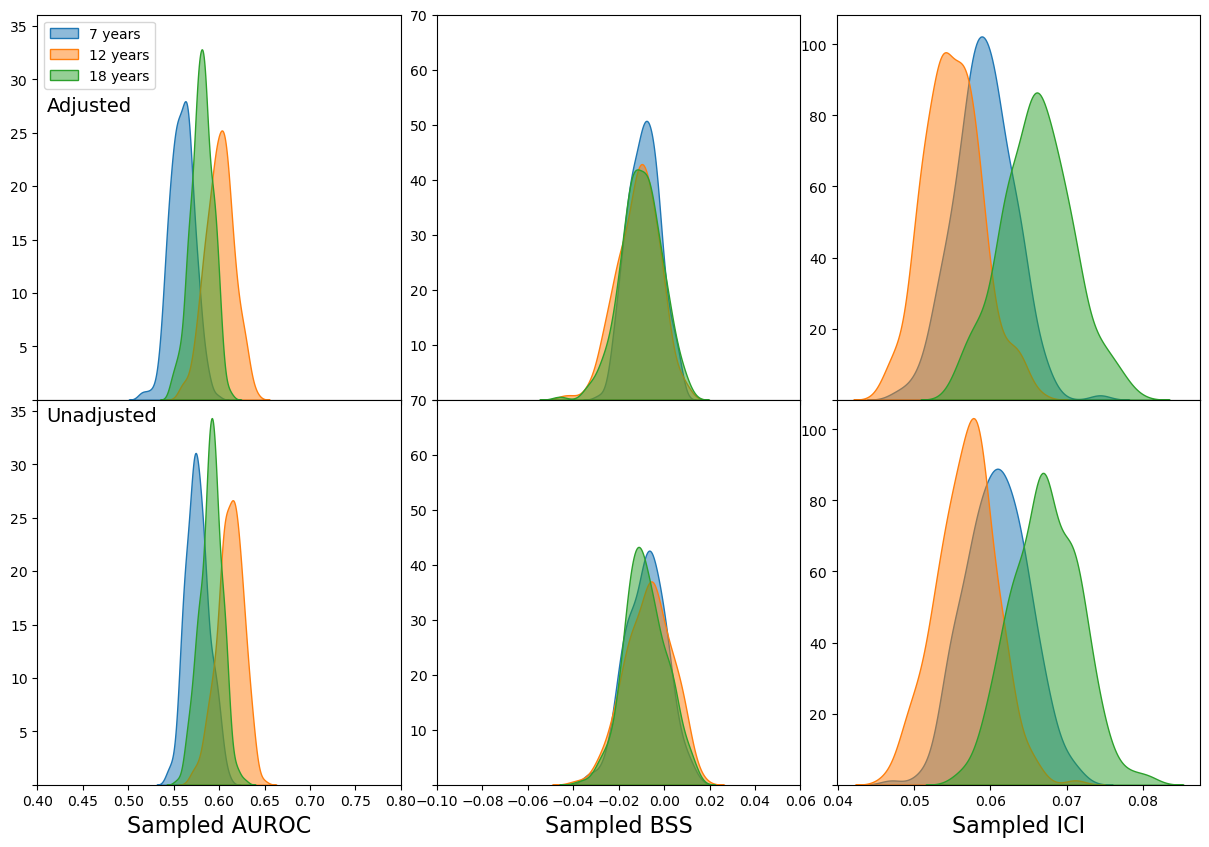

In [12]:
fig,ax=plt.subplots(2,3,figsize=(15,10),sharex="col",sharey="col", gridspec_kw={'wspace': 0.1, 'hspace': 0.00})
sns.kdeplot(data_7['performance_test']["roc_test"].mean(axis=0),ax=ax[0,0],fill=True,alpha=0.5,label="7 years")
sns.kdeplot(data_12['performance_test']["roc_test"].mean(axis=0),ax=ax[0,0],fill=True,alpha=0.5,label="12 years")
sns.kdeplot(data_18['performance_test']["roc_test"].mean(axis=0),ax=ax[0,0],fill=True,alpha=0.5,label="18 years")
ax[0,0].set_xlabel("Sampled AUROC",fontsize=16)
ax[0,0].legend(loc=2)
ax[0,0].set_xlim(0.4,0.7)
sns.kdeplot(data_7['performance_test']["bss_test"].mean(axis=0),ax=ax[0,1],fill=True,alpha=0.5,label="7 years adjusted BSS: "+str(np.round(data_7_ad['summary']['mean_per_fold_bss'],2)))
sns.kdeplot(data_12['performance_test']["bss_test"].mean(axis=0),ax=ax[0,1],fill=True,alpha=0.5,label="12 years adjusted BSS: "+str(np.round(data_12_ad['summary']['mean_per_fold_bss'],2)))
sns.kdeplot(data_18['performance_test']["bss_test"].mean(axis=0),ax=ax[0,1],fill=True,alpha=0.5,label="18 years adjusted BSS: "+str(np.round(data_18_ad['summary']['mean_per_fold_bss'],2)))


ax[0,1].set_xlabel("Sampled BSS",fontsize=16)
ax[0,1].set_xlim(-0.1,0.06)

sns.kdeplot(data_7['performance_test']["ici_test"].mean(axis=0),ax=ax[0,2],fill=True,alpha=0.5,label="7 years adjusted ICI: "+str(np.round(data_7_ad['summary']['mean_per_fold_ici'],2)))
sns.kdeplot(data_12['performance_test']["ici_test"].mean(axis=0),ax=ax[0,2],fill=True,alpha=0.5,label="12 years adjusted ICI: "+str(np.round(data_12_ad['summary']['mean_per_fold_ici'],2)))

sns.kdeplot(data_18['performance_test']["ici_test"].mean(axis=0),ax=ax[0,2],fill=True,alpha=0.5,label="18 years adjusted ICI: "+str(np.round(data_18_ad['summary']['mean_per_fold_ici'],2)))

ax[0,2].set_xlabel("Sampled ICI",fontsize=16)



sns.kdeplot(data_7_ad['performance_test']["roc_test"].mean(axis=0),ax=ax[1,0],fill=True,alpha=0.5,label="7 years ROC: "+str(np.round(data_7['summary']['mean_per_fold_roc'],2)))
sns.kdeplot(data_12_ad['performance_test']["roc_test"].mean(axis=0),ax=ax[1,0],fill=True,alpha=0.5,label="12 years ROC: "+str(np.round(data_12['summary']['mean_per_fold_roc'],2)))
sns.kdeplot(data_18_ad['performance_test']["roc_test"].mean(axis=0),ax=ax[1,0],fill=True,alpha=0.5,label="18 years ROC: "+str(np.round(data_18['summary']['mean_per_fold_roc'],2)))
ax[1,0].set_xlabel("Sampled AUROC",fontsize=16)

ax[1,0].set_xlim(0.4,0.7)

sns.kdeplot(data_7_ad['performance_test']["bss_test"].mean(axis=0),ax=ax[1,1],fill=True,alpha=0.5,label="7 years BSS: "+str(np.round(data_7['summary']['mean_per_fold_bss'],2)))
sns.kdeplot(data_12_ad['performance_test']["bss_test"].mean(axis=0),ax=ax[1,1],fill=True,alpha=0.5,label="12 years BSS: "+str(np.round(data_12['summary']['mean_per_fold_bss'],2)))
sns.kdeplot(data_18_ad['performance_test']["bss_test"].mean(axis=0),ax=ax[1,1],fill=True,alpha=0.5,label="18 years BSS: "+str(np.round(data_7['summary']['mean_per_fold_bss'],2)))



ax[1,1].set_xlabel("Sampled BSS",fontsize=16)
ax[1,1].set_xlim(-0.1,0.06)
sns.kdeplot(data_7_ad['performance_test']["ici_test"].mean(axis=0),ax=ax[1,2],fill=True,alpha=0.5,label="7 years ICI: "+str(np.round(data_7['summary']['mean_per_fold_ici'],2)))
sns.kdeplot(data_12_ad['performance_test']["ici_test"].mean(axis=0),ax=ax[1,2],fill=True,alpha=0.5,label="12 years ICI: "+str(np.round(data_12['summary']['mean_per_fold_ici'],2)))

sns.kdeplot(data_18_ad['performance_test']["ici_test"].mean(axis=0),ax=ax[1,2],fill=True,alpha=0.5,label="18 years ICI: "+str(np.round(data_18['summary']['mean_per_fold_ici'],2)))

ax[1,2].set_xlabel("Sampled ICI",fontsize=16)
for i in range(2):
    for j in range(3):
        # "Density" only on the leftmost column
        ax[i, j].set_ylabel("" if j == 0 else "", fontsize=18)
        # blank the 0 label so it doesn't collide with the panel below (hspace=0)
        ax[i, j].yaxis.set_major_formatter(
            FuncFormatter(lambda v, pos: "" if abs(v) < 1e-12 else f"{v:g}")
        )
ax[0,1].set_ylim(0,70)
ax[0,1].set_ylim(0,70)
ax[1,0].set_xlim(0.4,.8)

ax[0,0].text(0.41, 27, r'Adjusted', dict(size=14),c="k")
ax[1,0].text(0.41,  34, r'Unadjusted', dict(size=14),c="k")

fig.savefig("../Plots/sampled_performence.png",bbox_inches="tight",dpi=300)

In [20]:
train_roc=np.array([data_7['summary']["pooled_oof_roc_train"].mean(),data_12['summary']["pooled_oof_roc_train"].mean(),data_18['summary']["pooled_oof_roc_train"].mean()])
test_roc=np.array([data_7['summary']["pooled_oof_roc_test"].mean(),data_12['summary']["pooled_oof_roc_test"].mean(),data_18['summary']["pooled_oof_roc_test"].mean()])
train_bss=np.array([data_7['summary']["pooled_oof_bss_train"].mean(),data_12['summary']["pooled_oof_bss_train"].mean(),data_18['summary']["pooled_oof_bss_train"].mean()])
test_bss=np.array([data_7['summary']["pooled_oof_bss_test"].mean(),data_12['summary']["pooled_oof_bss_test"].mean(),data_18['summary']["pooled_oof_bss_test"].mean()])
train_ici=np.array([data_7['summary']["pooled_oof_ici_train"].mean(),data_12['summary']["pooled_oof_ici_train"].mean(),data_18['summary']["pooled_oof_ici_train"].mean()])
test_ici=np.array([data_7['summary']["pooled_oof_ici_test"].mean(),data_12['summary']["pooled_oof_ici_test"].mean(),data_18['summary']["pooled_oof_ici_test"].mean()])

train_roc_std=np.array([data_7['summary']["pooled_oof_roc_train"].std(),data_12['summary']["pooled_oof_roc_train"].std(),data_18['summary']["pooled_oof_roc_train"].std()])
test_roc_std=np.array([data_7['summary']["pooled_oof_roc_test"].std(),data_12['summary']["pooled_oof_roc_test"].std(),data_18['summary']["pooled_oof_roc_test"].std()])
train_bss_std=np.array([data_7['summary']["pooled_oof_bss_train"].std(),data_12['summary']["pooled_oof_bss_train"].std(),data_18['summary']["pooled_oof_bss_train"].std()])
test_bss_std=np.array([data_7['summary']["pooled_oof_bss_test"].std(),data_12['summary']["pooled_oof_bss_test"].std(),data_18['summary']["pooled_oof_bss_test"].std()])
train_ici_std=np.array([data_7['summary']["pooled_oof_ici_train"].std(),data_12['summary']["pooled_oof_ici_train"].std(),data_18['summary']["pooled_oof_ici_train"].std()])
test_ici_std=np.array([data_7['summary']["pooled_oof_ici_test"].std(),data_12['summary']["pooled_oof_ici_test"].std(),data_18['summary']["pooled_oof_ici_test"].std()])


In [21]:
train_roc_ad=np.array([data_7_ad['summary']["pooled_oof_roc_train"].mean(),data_12_ad['summary']["pooled_oof_roc_train"].mean(),data_18_ad['summary']["pooled_oof_roc_train"].mean()])
test_roc_ad=np.array([data_7_ad['summary']["pooled_oof_roc_test"].mean(),data_12_ad['summary']["pooled_oof_roc_test"].mean(),data_18_ad['summary']["pooled_oof_roc_test"].mean()])
train_bss_ad=np.array([data_7_ad['summary']["pooled_oof_bss_train"].mean(),data_12_ad['summary']["pooled_oof_bss_train"].mean(),data_18_ad['summary']["pooled_oof_bss_train"].mean()])
test_bss_ad=np.array([data_7_ad['summary']["pooled_oof_bss_test"].mean(),data_12_ad['summary']["pooled_oof_bss_test"].mean(),data_18_ad['summary']["pooled_oof_bss_test"].mean()])
train_ici_ad=np.array([data_7_ad['summary']["pooled_oof_ici_train"].mean(),data_12_ad['summary']["pooled_oof_ici_train"].mean(),data_18_ad['summary']["pooled_oof_ici_train"].mean()])
test_ici_ad=np.array([data_7_ad['summary']["pooled_oof_ici_test"].mean(),data_12_ad['summary']["pooled_oof_ici_test"].mean(),data_18_ad['summary']["pooled_oof_ici_test"].mean()])

train_roc_ad_std=np.array([data_7_ad['summary']["pooled_oof_roc_train"].std(),data_12_ad['summary']["pooled_oof_roc_train"].std(),data_18_ad['summary']["pooled_oof_roc_train"].std()])
test_roc_ad_std=np.array([data_7_ad['summary']["pooled_oof_roc_test"].std(),data_12_ad['summary']["pooled_oof_roc_test"].std(),data_18_ad['summary']["pooled_oof_roc_test"].std()])
train_bss_ad_std=np.array([data_7_ad['summary']["pooled_oof_bss_train"].std(),data_12_ad['summary']["pooled_oof_bss_train"].std(),data_18_ad['summary']["pooled_oof_bss_train"].std()])
test_bss_ad_std=np.array([data_7_ad['summary']["pooled_oof_bss_test"].std(),data_12_ad['summary']["pooled_oof_bss_test"].std(),data_18_ad['summary']["pooled_oof_bss_test"].std()])
train_ici_ad_std=np.array([data_7_ad['summary']["pooled_oof_ici_train"].std(),data_12_ad['summary']["pooled_oof_ici_train"].std(),data_18_ad['summary']["pooled_oof_ici_train"].std()])
test_ici_ad_std=np.array([data_7_ad['summary']["pooled_oof_ici_test"].std(),data_12_ad['summary']["pooled_oof_ici_test"].std(),data_18_ad['summary']["pooled_oof_ici_test"].std()])


In [22]:
data_7_rf

{'summary': {'model': 'calibrated_rf_tuned',
  'calibration': 'isotonic',
  'prevalence': 0.17518248175182483,
  'baseline_brier': 0.1444935798390964,
  'pooled_oof_roc': 0.5896017699115044,
  'pooled_oof_brier': 0.14203459749737274,
  'pooled_oof_bss': 0.017017934945358082,
  'pooled_oof_ici': 0.03158313794988831},
 'test_perf': {'roc_test': array([0.60735294, 0.62972689, 0.64653361, 0.4532563 , 0.52985075,
         0.57794118, 0.63497899, 0.51260504, 0.58245798, 0.66616915,
         0.56519608, 0.51838235, 0.49264706, 0.66334034, 0.71393035,
         0.55539216, 0.66334034, 0.75997899, 0.62184874, 0.44378109,
         0.63480392, 0.55619748, 0.65493697, 0.58403361, 0.59253731]),
  'brier_test': array([0.14888578, 0.13373822, 0.13213032, 0.15751693, 0.15285339,
         0.14611372, 0.13890987, 0.14835329, 0.14251538, 0.13825772,
         0.14796074, 0.15954518, 0.15842986, 0.13133052, 0.13527404,
         0.14925385, 0.13395829, 0.130181  , 0.13437998, 0.17295677,
         0.14647912,

In [23]:
test_roc_rf=np.array([data_7_rf['test_perf']["roc_test"].mean(),data_12_rf['test_perf']["roc_test"].mean(),data_18_rf['test_perf']["roc_test"].mean()])
train_roc_rf=np.array([data_7_rf['train_perf']["roc_train"].mean(),data_12_rf['train_perf']["roc_train"].mean(),data_18_rf['train_perf']["roc_train"].mean()])
train_bss_rf=np.array([data_7_rf['train_perf']["bss_train"].mean(),data_12_rf['train_perf']["bss_train"].mean(),data_18_rf['train_perf']["bss_train"].mean()])
test_bss_rf=np.array([data_7_rf['test_perf']["bss_test"].mean(),data_12_rf['test_perf']["bss_test"].mean(),data_18_rf['test_perf']["bss_test"].mean()])
train_ici_rf=np.array([data_7_rf['train_perf']["ici_train"].mean(),data_12_rf['train_perf']["ici_train"].mean(),data_18_rf['train_perf']["ici_train"].mean()])
test_ici_rf=np.array([data_7_rf['test_perf']["ici_test"].mean(),data_12_rf['test_perf']["ici_test"].mean(),data_18_rf['test_perf']["ici_test"].mean()])

In [24]:
test_roc_rf_std=np.array([data_7_rf['test_perf']["roc_test"].std(),data_12_rf['test_perf']["roc_test"].std(),data_18_rf['test_perf']["roc_test"].std()])
train_roc_rf_std=np.array([data_7_rf['train_perf']["roc_train"].std(),data_12_rf['train_perf']["roc_train"].std(),data_18_rf['train_perf']["roc_train"].std()])
train_bss_rf_std=np.array([data_7_rf['train_perf']["bss_train"].std(),data_12_rf['train_perf']["bss_train"].std(),data_18_rf['train_perf']["bss_train"].std()])
test_bss_rf_std=np.array([data_7_rf['test_perf']["bss_test"].std(),data_12_rf['test_perf']["bss_test"].std(),data_18_rf['test_perf']["bss_test"].std()])
train_ici_rf_std=np.array([data_7_rf['train_perf']["ici_train"].std(),data_12_rf['train_perf']["ici_train"].std(),data_18_rf['train_perf']["ici_train"].std()])
test_ici_rf_std=np.array([data_7_rf['test_perf']["ici_test"].std(),data_12_rf['test_perf']["ici_test"].std(),data_18_rf['test_perf']["ici_test"].std()])

In [25]:
test_roc_rf_ad=np.array([data_7_rf_ad['test_perf']["roc_test"].mean(),data_12_rf_ad['test_perf']["roc_test"].mean(),data_18_rf_ad['test_perf']["roc_test"].mean()])
train_roc_rf_ad=np.array([data_7_rf_ad['train_perf']["roc_train"].mean(),data_12_rf_ad['train_perf']["roc_train"].mean(),data_18_rf_ad['train_perf']["roc_train"].mean()])
train_bss_rf_ad=np.array([data_7_rf_ad['train_perf']["bss_train"].mean(),data_12_rf_ad['train_perf']["bss_train"].mean(),data_18_rf_ad['train_perf']["bss_train"].mean()])
test_bss_rf_ad=np.array([data_7_rf_ad['test_perf']["bss_test"].mean(),data_12_rf_ad['test_perf']["bss_test"].mean(),data_18_rf_ad['test_perf']["bss_test"].mean()])
train_ici_rf_ad=np.array([data_7_rf_ad['train_perf']["ici_train"].mean(),data_12_rf_ad['train_perf']["ici_train"].mean(),data_18_rf_ad['train_perf']["ici_train"].mean()])
test_ici_rf_ad=np.array([data_7_rf_ad['test_perf']["ici_test"].mean(),data_12_rf_ad['test_perf']["ici_test"].mean(),data_18_rf_ad['test_perf']["ici_test"].mean()])

In [26]:
test_roc_rf_ad_std=np.array([data_7_rf_ad['test_perf']["roc_test"].std(),data_12_rf_ad['test_perf']["roc_test"].std(),data_18_rf_ad['test_perf']["roc_test"].std()])
train_roc_rf_ad_std=np.array([data_7_rf_ad['train_perf']["roc_train"].std(),data_12_rf_ad['train_perf']["roc_train"].std(),data_18_rf_ad['train_perf']["roc_train"].std()])
train_bss_rf_ad_std=np.array([data_7_rf_ad['train_perf']["bss_train"].std(),data_12_rf_ad['train_perf']["bss_train"].std(),data_18_rf_ad['train_perf']["bss_train"].std()])
test_bss_rf_ad_std=np.array([data_7_rf_ad['test_perf']["bss_test"].std(),data_12_rf_ad['test_perf']["bss_test"].std(),data_18_rf_ad['test_perf']["bss_test"].std()])
train_ici_rf_ad_std=np.array([data_7_rf_ad['train_perf']["ici_train"].std(),data_12_rf_ad['train_perf']["ici_train"].std(),data_18_rf_ad['train_perf']["ici_train"].std()])
test_ici_rf_ad_std=np.array([data_7_rf_ad['test_perf']["ici_test"].std(),data_12_rf_ad['test_perf']["ici_test"].std(),data_18_rf_ad['test_perf']["ici_test"].std()])

In [27]:
data_7_rf_ad['test_perf']["roc_test"]

array([0.71764706, 0.76155462, 0.60084034, 0.54569328, 0.65472637,
       0.60931373, 0.78834034, 0.62762605, 0.64180672, 0.76218905,
       0.63480392, 0.62237395, 0.65073529, 0.64390756, 0.66218905,
       0.68137255, 0.67069328, 0.74737395, 0.75892857, 0.49800995,
       0.75931373, 0.68067227, 0.69590336, 0.62762605, 0.69751244])

In [28]:
test_bss_rf

array([-0.00122911,  0.01239688, -0.02142238])

In [29]:
x=np.array([1,2,3])

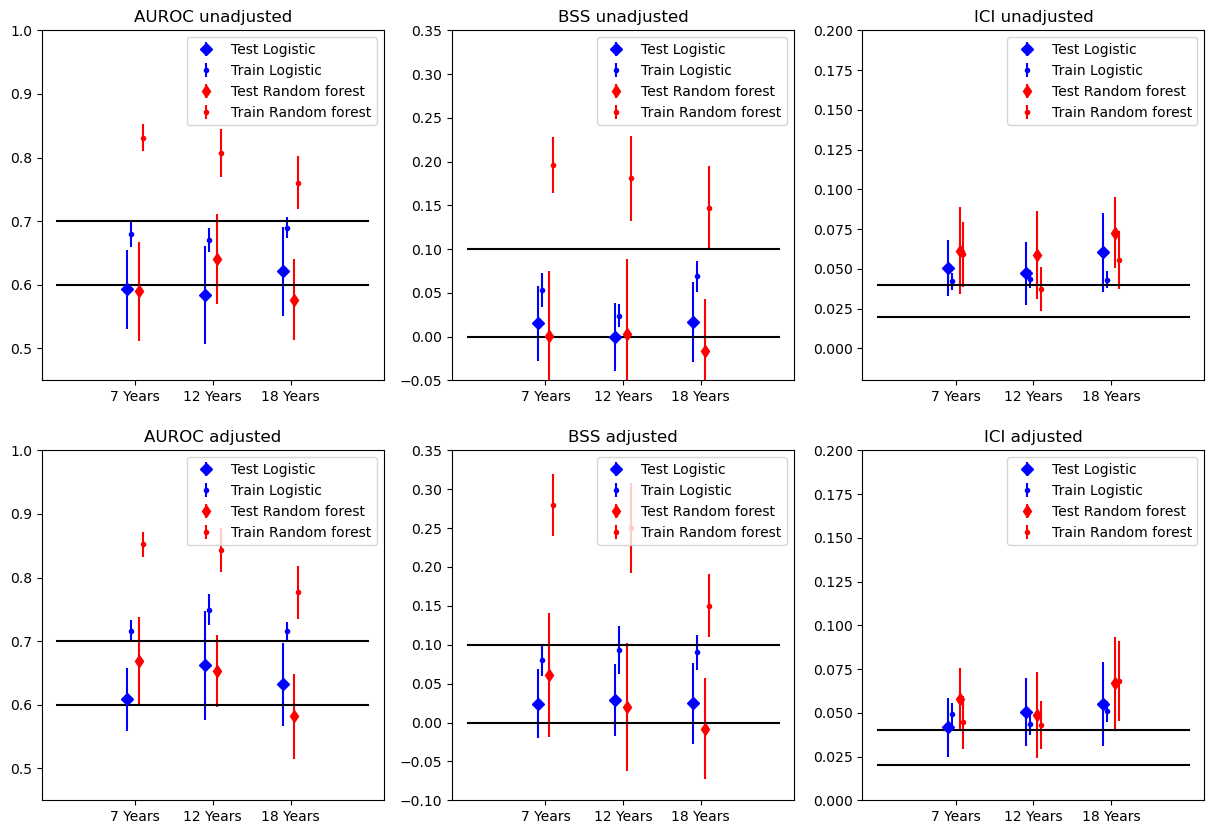

In [17]:
fig,ax=plt.subplots(2,3,figsize=(15,10))

ax[0,0].errorbar(x-0.1,test_roc,yerr=test_roc_std,fmt='Db',label="Test Logistic")
ax[0,0].errorbar(x-0.05,train_roc,yerr=train_roc_std,fmt='.b',label="Train Logistic")


ax[0,0].errorbar(x+0.05,test_roc_rf,yerr=test_roc_rf_std,fmt='dr',label="Test Random forest")
ax[0,0].errorbar(x+0.1,train_roc_rf,yerr=train_roc_rf_std,fmt='.r',label="Train Random forest")


ax[0,0].plot(np.arange(0,5),np.ones(5)*0.6,"k")
ax[0,0].plot(np.arange(0,5),np.ones(5)*0.7,"k")

ax[0,0].legend(loc=1)
ax[0,0].set_ylim(0.45,1)
ax[0,0].set_xticks(x,["7 Years","12 Years","18 Years"])

ax[0,0].set_title('AUROC unadjusted')

ax[0,1].errorbar(x-0.1,test_bss,yerr=test_bss_std,fmt='Db',label="Test Logistic")
ax[0,1].errorbar(x-0.05,train_bss,yerr=train_bss_std,fmt='.b',label="Train Logistic")


ax[0,1].errorbar(x+0.05,test_bss_rf,yerr=test_bss_rf_std,fmt='dr',label="Test Random forest")
ax[0,1].errorbar(x+0.1,train_bss_rf,yerr=train_bss_rf_std,fmt='.r',label="Train Random forest")


ax[0,1].plot(np.arange(0,5),np.ones(5)*0.1,"k")
ax[0,1].plot(np.arange(0,5),np.ones(5)*0.0,"k")
ax[0,1].legend(loc=1)

ax[0,1].set_xticks(x,["7 Years","12 Years","18 Years"])
ax[0,1].set_title('BSS unadjusted')

ax[0,1].set_ylim(-0.05,0.35)



ax[0,2].errorbar(x-0.1,test_ici,yerr=test_ici_std,fmt='Db',label="Test Logistic")
ax[0,2].errorbar(x-0.05,train_ici,yerr=train_ici_std,fmt='.b',label="Train Logistic")


ax[0,2].errorbar(x+0.05,test_ici_rf,yerr=test_ici_rf_std,fmt='dr',label="Test Random forest")
ax[0,2].errorbar(x+0.1,train_ici_rf,yerr=train_ici_rf_std,fmt='.r',label="Train Random forest")


ax[0,2].plot(np.arange(0,5),np.ones(5)*0.04,"k")
ax[0,2].plot(np.arange(0,5),np.ones(5)*0.02,"k")
ax[0,2].legend(loc=1)

ax[0,2].set_xticks(x,["7 Years","12 Years","18 Years"])
ax[0,2].set_title('ICI unadjusted')

ax[0,2].set_ylim(-0.02,0.2)


ax[1,0].set_title('AUROC adjusted')

ax[1,0].errorbar(x-0.1,test_roc_ad,yerr=test_roc_ad_std,fmt='Db',label="Test Logistic")
ax[1,0].errorbar(x-0.05,train_roc_ad,yerr=train_roc_ad_std,fmt='.b',label="Train Logistic")


ax[1,0].errorbar(x+0.05,test_roc_rf_ad,yerr=test_roc_rf_ad_std,fmt='dr',label="Test Random forest")
ax[1,0].errorbar(x+0.1,train_roc_rf_ad,yerr=train_roc_rf_ad_std,fmt='.r',label="Train Random forest")


ax[1,0].plot(np.arange(0,5),np.ones(5)*0.6,"k")
ax[1,0].plot(np.arange(0,5),np.ones(5)*0.7,"k")
ax[1,0].legend(loc=1)
ax[1,0].set_ylim(0.45,1)
ax[1,0].set_xticks(x,["7 Years","12 Years","18 Years"])

ax[1,0].set_title('AUROC adjusted')

ax[1,1].errorbar(x-0.1,test_bss_ad,yerr=test_bss_ad_std,fmt='Db',label="Test Logistic")
ax[1,1].errorbar(x-0.05,train_bss_ad,yerr=train_bss_ad_std,fmt='.b',label="Train Logistic")


ax[1,1].errorbar(x+0.05,test_bss_rf_ad,yerr=test_bss_rf_ad_std,fmt='dr',label="Test Random forest")
ax[1,1].errorbar(x+0.1,train_bss_rf_ad,yerr=train_bss_rf_ad_std,fmt='.r',label="Train Random forest")


ax[1,1].plot(np.arange(0,5),np.ones(5)*0.1,"k")
ax[1,1].plot(np.arange(0,5),np.ones(5)*0.0,"k")
ax[1,1].legend(loc=1)

ax[1,1].set_xticks(x,["7 Years","12 Years","18 Years"])
ax[1,1].set_title('BSS adjusted')

ax[1,1].set_ylim(-0.1,0.35)

ax[1,2].errorbar(x-0.1,test_ici_ad,yerr=test_ici_ad_std,fmt='Db',label="Test Logistic")
ax[1,2].errorbar(x-0.05,train_ici_ad,yerr=train_ici_ad_std,fmt='.b',label="Train Logistic")


ax[1,2].errorbar(x+0.05,test_ici_rf_ad,yerr=test_ici_rf_ad_std,fmt='dr',label="Test Random forest")
ax[1,2].errorbar(x+0.1,train_ici_rf_ad,yerr=train_ici_rf_ad_std,fmt='.r',label="Train Random forest")


ax[1,2].plot(np.arange(0,5),np.ones(5)*0.04,"k")
ax[1,2].plot(np.arange(0,5),np.ones(5)*0.02,"k")
ax[1,2].legend(loc=1)

ax[1,2].set_xticks(x,["7 Years","12 Years","18 Years"])
ax[1,2].set_title('ICI adjusted')

ax[1,2].set_ylim(0,0.2)



fig.savefig("../Plots/performence_pulled.png",bbox_inches="tight")